In [1]:
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict 

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [5]:
ROOT = Path("Classes")

# find all paths
files = [file for file in ROOT.rglob("*") if file.is_file() and not file.name.startswith(".")]

In [3]:
# check file extension
extensions = [file.suffix.lower() for file in files]
ext_counts = pd.Series(extensions).value_counts()
pd.set_option('display.max_colwidth', 80)
print("Top 10 file extensions:")
print(ext_counts.head(10))

Top 10 file extensions:
.jpg     45591
.jpeg    45163
.png     11959
Name: count, dtype: int64


In [4]:
data_list = [] 

for file in files:
    try:
        with Image.open(file) as img:
            w, h = img.size
            data_list.append([str(file), 
                              len(file.relative_to(ROOT).parts),
                              file.stem,
                              file.suffix.lstrip("."), 
                              w, 
                              h
                             ])
    except Exception as e:
        continue

# Convert list to DataFrame
data = pd.DataFrame(
    data_list, 
    columns=["file_path", "depth", "file_name", "file_ext", "width", "height"]
)

In [6]:
data.shape

(102713, 6)

In [7]:
data.head()

,file_path,depth,file_name,file_ext,width,height
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102713 entries, 0 to 102712
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   file_path  102713 non-null  object
 1   depth      102713 non-null  int64 
 2   file_name  102713 non-null  object
 3   file_ext   102713 non-null  object
 4   width      102713 non-null  int64 
 5   height     102713 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.7+ MB


In [9]:
data.describe()

,depth,width,height
count,102713.000000,102713.000000,102713.000000
mean,3.065367,462.774741,429.986136
std,0.247173,168.250166,122.454167
min,3.000000,90.000000,90.000000
25%,3.000000,375.000000,374.000000
50%,3.000000,500.000000,500.000000
75%,3.000000,500.000000,500.000000
max,4.000000,1280.000000,1024.000000


#### Depth shows the number of folders away a file is from your starting point (ROOT)

In [11]:
# checking the 
depths = []
for f in ROOT.rglob("*"):
    if f.is_file():
        depths.append(len(f.relative_to(ROOT).parts))

print("Depths:", set(depths))
for d in sorted(set(depths)):
    print(f"Depth {d}: {depths.count(d)} files")

Depths: {1, 2, 3, 4}
Depth 1: 1 files
Depth 2: 1 files
Depth 3: 95999 files
Depth 4: 6714 files


In [12]:
print("\nSample files with depth 4:")
data[data['depth'] == 3].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512


In [13]:
print("\nSample files with depth 4:")
data[data['depth'] == 4].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575


#### aspeact ratio - consistency to prevent the images being stretched or squished.
#### megapixel - image quality control(not blurry) and check hardware limits
#### orientation - landscape vs. portrait

In [17]:
# checking the images
data["aspect_ratio"] = data["width"] / data["height"]
data["megapixels"] = (data["width"] * data["height"]) / 1_000_000
data["orientation"] = np.where(data["aspect_ratio"] > 1, "landscape", np.where(data["aspect_ratio"] < 1, "portrait", "square"))

# some AI models only detect square image
square_images = data[data["orientation"] == "square"]
print(f"1. Square images: {len(square_images)}")

# find high-resolution images
high_res = data[data["megapixels"] > 1.0]
print(f"\n2. High-res images (>1MP): {len(high_res)}")

# check orientation distribution
orientation_counts = data["orientation"].value_counts()
print("\n3. Orientation distribution:")
print(orientation_counts)

# find extreme aspect ratios 
extreme = data[(data["aspect_ratio"] > 3) | (data["aspect_ratio"] < 0.33)]
print(f"\n4. Extreme aspect ratios: {len(extreme)}")

1. Square images: 8648

2. High-res images (>1MP): 434

3. Orientation distribution:
orientation
landscape    55282
portrait     38783
square        8648
Name: count, dtype: int64

4. Extreme aspect ratios: 13


In [18]:
# check for unique depths
unique_depths = sorted(set(len(f.relative_to(ROOT).parts) for f in files))
print(f"Unique depth levels found: {unique_depths}")

Unique depth levels found: [3, 4]


In [23]:
# only check depth 3 and 4 and count
depth3_count = sum(1 for f in files if len(f.relative_to(ROOT).parts) == 3)
depth4_count = sum(1 for f in files if len(f.relative_to(ROOT).parts) == 4)

print(f"Depth 3 files: {depth3_count:,} ({depth3_count/len(files)*100:.1f}%)")
print(f"Depth 4 files: {depth4_count:,} ({depth4_count/len(files)*100:.1f}%)")

Depth 3 files: 95,999 (93.5%)
Depth 4 files: 6,714 (6.5%)


In [24]:
data[data['depth'] == 3]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, poisonous, Xanthoria parietina]               5837
[Classes, conditionally_edible, Fomes fomentarius]      5254
[Classes, conditionally_edible, Fomitopsis pinicola]    5096
[Classes, poisonous, Amanita muscaria]                  4258
[Classes, conditionally_edible, Parmelia sulcata]       2654
Name: count, dtype: int64

In [25]:
data[data['depth'] == 4]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, conditionally_edible, Mushrooms, Lactarius]      1563
[Classes, conditionally_edible, Mushrooms, Russula]        1148
[Classes, conditionally_edible, Mushrooms, Boletus]        1073
[Classes, conditionally_edible, Mushrooms, Cortinarius]     836
[Classes, conditionally_edible, Mushrooms, Amanita]         750
Name: count, dtype: int64

#### to find the series of species names
#### the path is split by '/', so take index 3 if depth is 4, or is index 2

In [62]:
raw_species = data.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

total = raw_species.nunique()
counts = raw_species.value_counts()

print(f"1. Total Unique Species Found: {total}")
print("\n2. *** Most 10 Species ***")
print(counts.head(10))
print("\n3. ***** Least 10 Species *****")
print(counts.tail(10))

1. Total Unique Species Found: 570

2. *** Most 10 Species ***
Xanthoria parietina      5837
Fomes fomentarius        5254
Fomitopsis pinicola      5096
Amanita muscaria         4258
Lactarius                3126
Parmelia sulcata         2654
Laetiporus sulphureus    2302
Russula                  2296
Hypogymnia physodes      2166
Boletus                  2146
Name: count, dtype: int64

3. ***** Least 10 Species *****
golden_bootleg         10
smoky_bracket          10
cedarwood_waxcap       10
oak_polypore           10
rooting_shank          10
cinnamon_bracket        9
orange_birch_bolete     8
devils_bolete           8
deadly_webcap           8
truffles                4
Name: count, dtype: int64


#### Cleaning and organizing the data
#### - adding class and species column

In [34]:
data['class'] = data['file_path'].apply(lambda x: x.split('/')[1])
data['species'] = data.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

In [35]:
data[data['depth'] == 3].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty


In [36]:
data[data['depth'] == 4].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,1.506591,0.4248,landscape,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,1.333333,0.4800,landscape,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,1.295000,0.4662,landscape,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,1.333333,0.4800,landscape,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,1.391304,0.4600,landscape,conditionally_edible,Agaricus


In [29]:
species_per_class = data.groupby('class')['species'].nunique()
print("Unique Species per Class:\n", species_per_class)

Unique Species per Class:
 class
conditionally_edible    175
deadly                   40
edible                  160
poisonous               214
Name: species, dtype: int64


In [58]:
images_per_class_top = data.groupby(['class', 'species']).size().groupby('class').nlargest(5)
print("\nTop 5 Species per Class by Image Count:\n", images_per_class_top)


Top 5 Species per Class by Image Count:
 class                 class                 species              
conditionally_edible  conditionally_edible  Fomes fomentarius        5254
                                            Fomitopsis pinicola      5096
                                            Lactarius                3126
                                            Parmelia sulcata         2654
                                            Laetiporus sulphureus    2302
deadly                deadly                Amanita_arocheae           49
                                            Amanita_bisporigera        48
                                            Galerina_marginata         45
                                            Clitocybe_rivulosa         35
                                            Omphalotus_illudens        35
edible                edible                Cerioporus squamosus     1523
                                            Coprinus comatus         1309
    

In [30]:
class_counts = data['class'].value_counts()
print("Full Class Distribution:\n", class_counts)
print("Unique Classes:", data['class'].unique())

Full Class Distribution:
 class
conditionally_edible    61968
poisonous               21138
edible                  18417
deadly                   1190
Name: count, dtype: int64
Unique Classes: ['conditionally_edible' 'poisonous' 'edible' 'deadly']


#### The Full Class Distribution shows imbalance of the dataset
####   - conditionally_edible has the most data (60.3%)
####   - deadly has the least data (1.2%)

- The graph shows the plot skews to the right.

- Imbalance data - when it is trained on naive model, it predicts well on dominating data, but not on least data.
If the model is used in the real world, it will be a very BIG issues - "deadly".


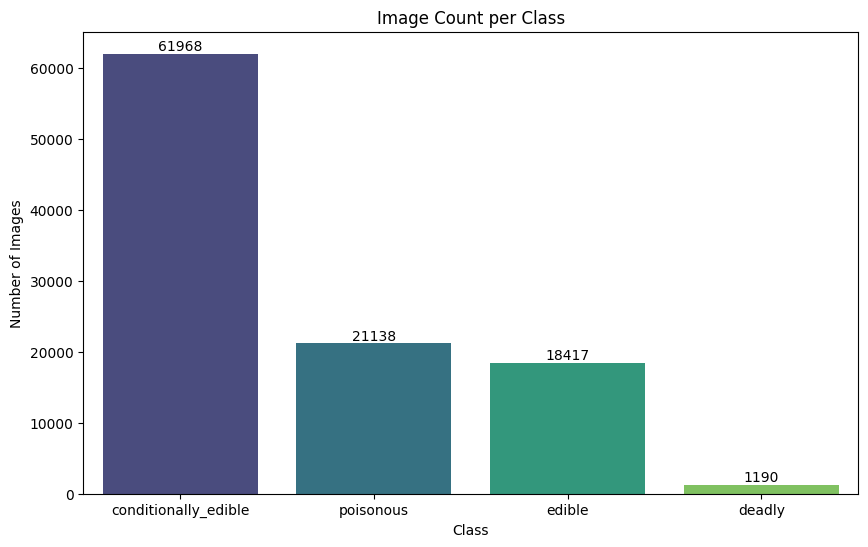

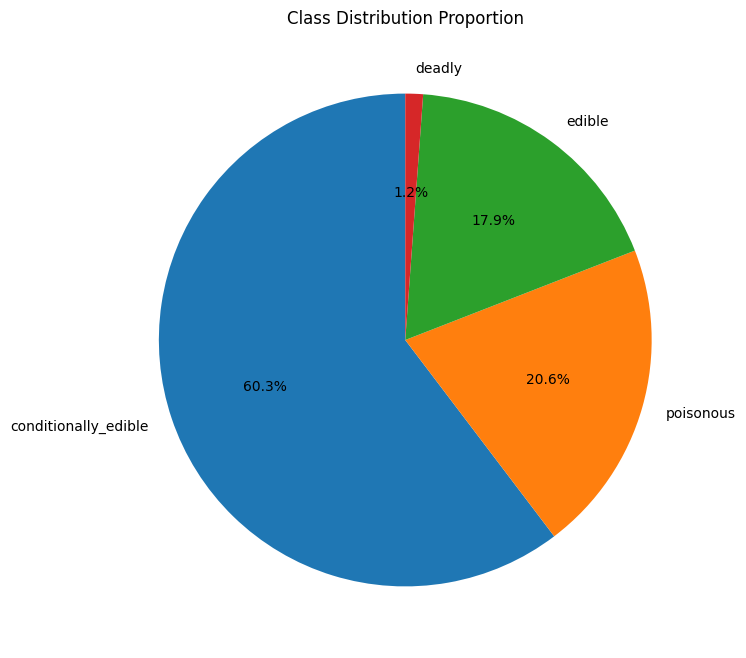

In [38]:
class_counts = data['class'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Image Count @ Class')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

# Pie chart for proportions
plt.figure(figsize=(8, 8))
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution Proportion')
plt.show()


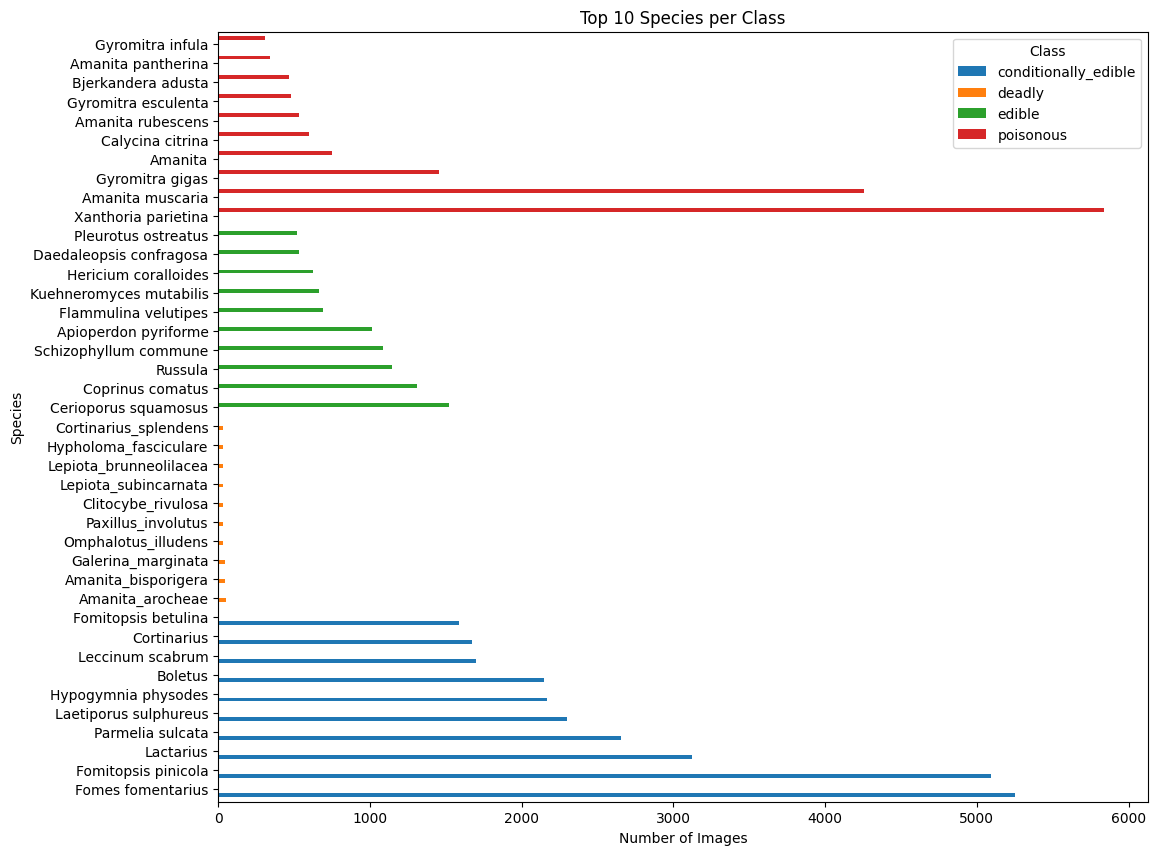

In [47]:
top_per_class = data.groupby('class')['species'].value_counts().groupby('class').head(10)

# Unstack for plotting
top_per_class.unstack(level=0).plot(kind='barh', figsize=(12, 10), width=0.8)
plt.title('Top 10 Species per Class')
plt.xlabel('Number of Images')
plt.ylabel('Species')
plt.legend(title='Class')
plt.show()

In [52]:
counts = data['species'].value_counts()
min_threshold = 50  # Try 30 or 50
kept_species = counts[counts >= min_threshold].index
filtered_data = data[data['species'].isin(kept_species)]

print(f"Original: {len(data)} images, {counts.size} species")
print(f"Filtered (>= {min_threshold} images/species): {len(filtered_data)} images ({len(filtered_data)/len(data)*100:.1f}%), {len(kept_species)} species")
print(f"Class distribution after filter:\n{filtered_data['class'].value_counts()}")

Original: 102713 images, 570 species
Filtered (>= 50 images/species): 92990 images (90.5%), 147 species
Class distribution after filter:
class
conditionally_edible    60535
poisonous               16447
edible                  15707
deadly                    301
Name: count, dtype: int64


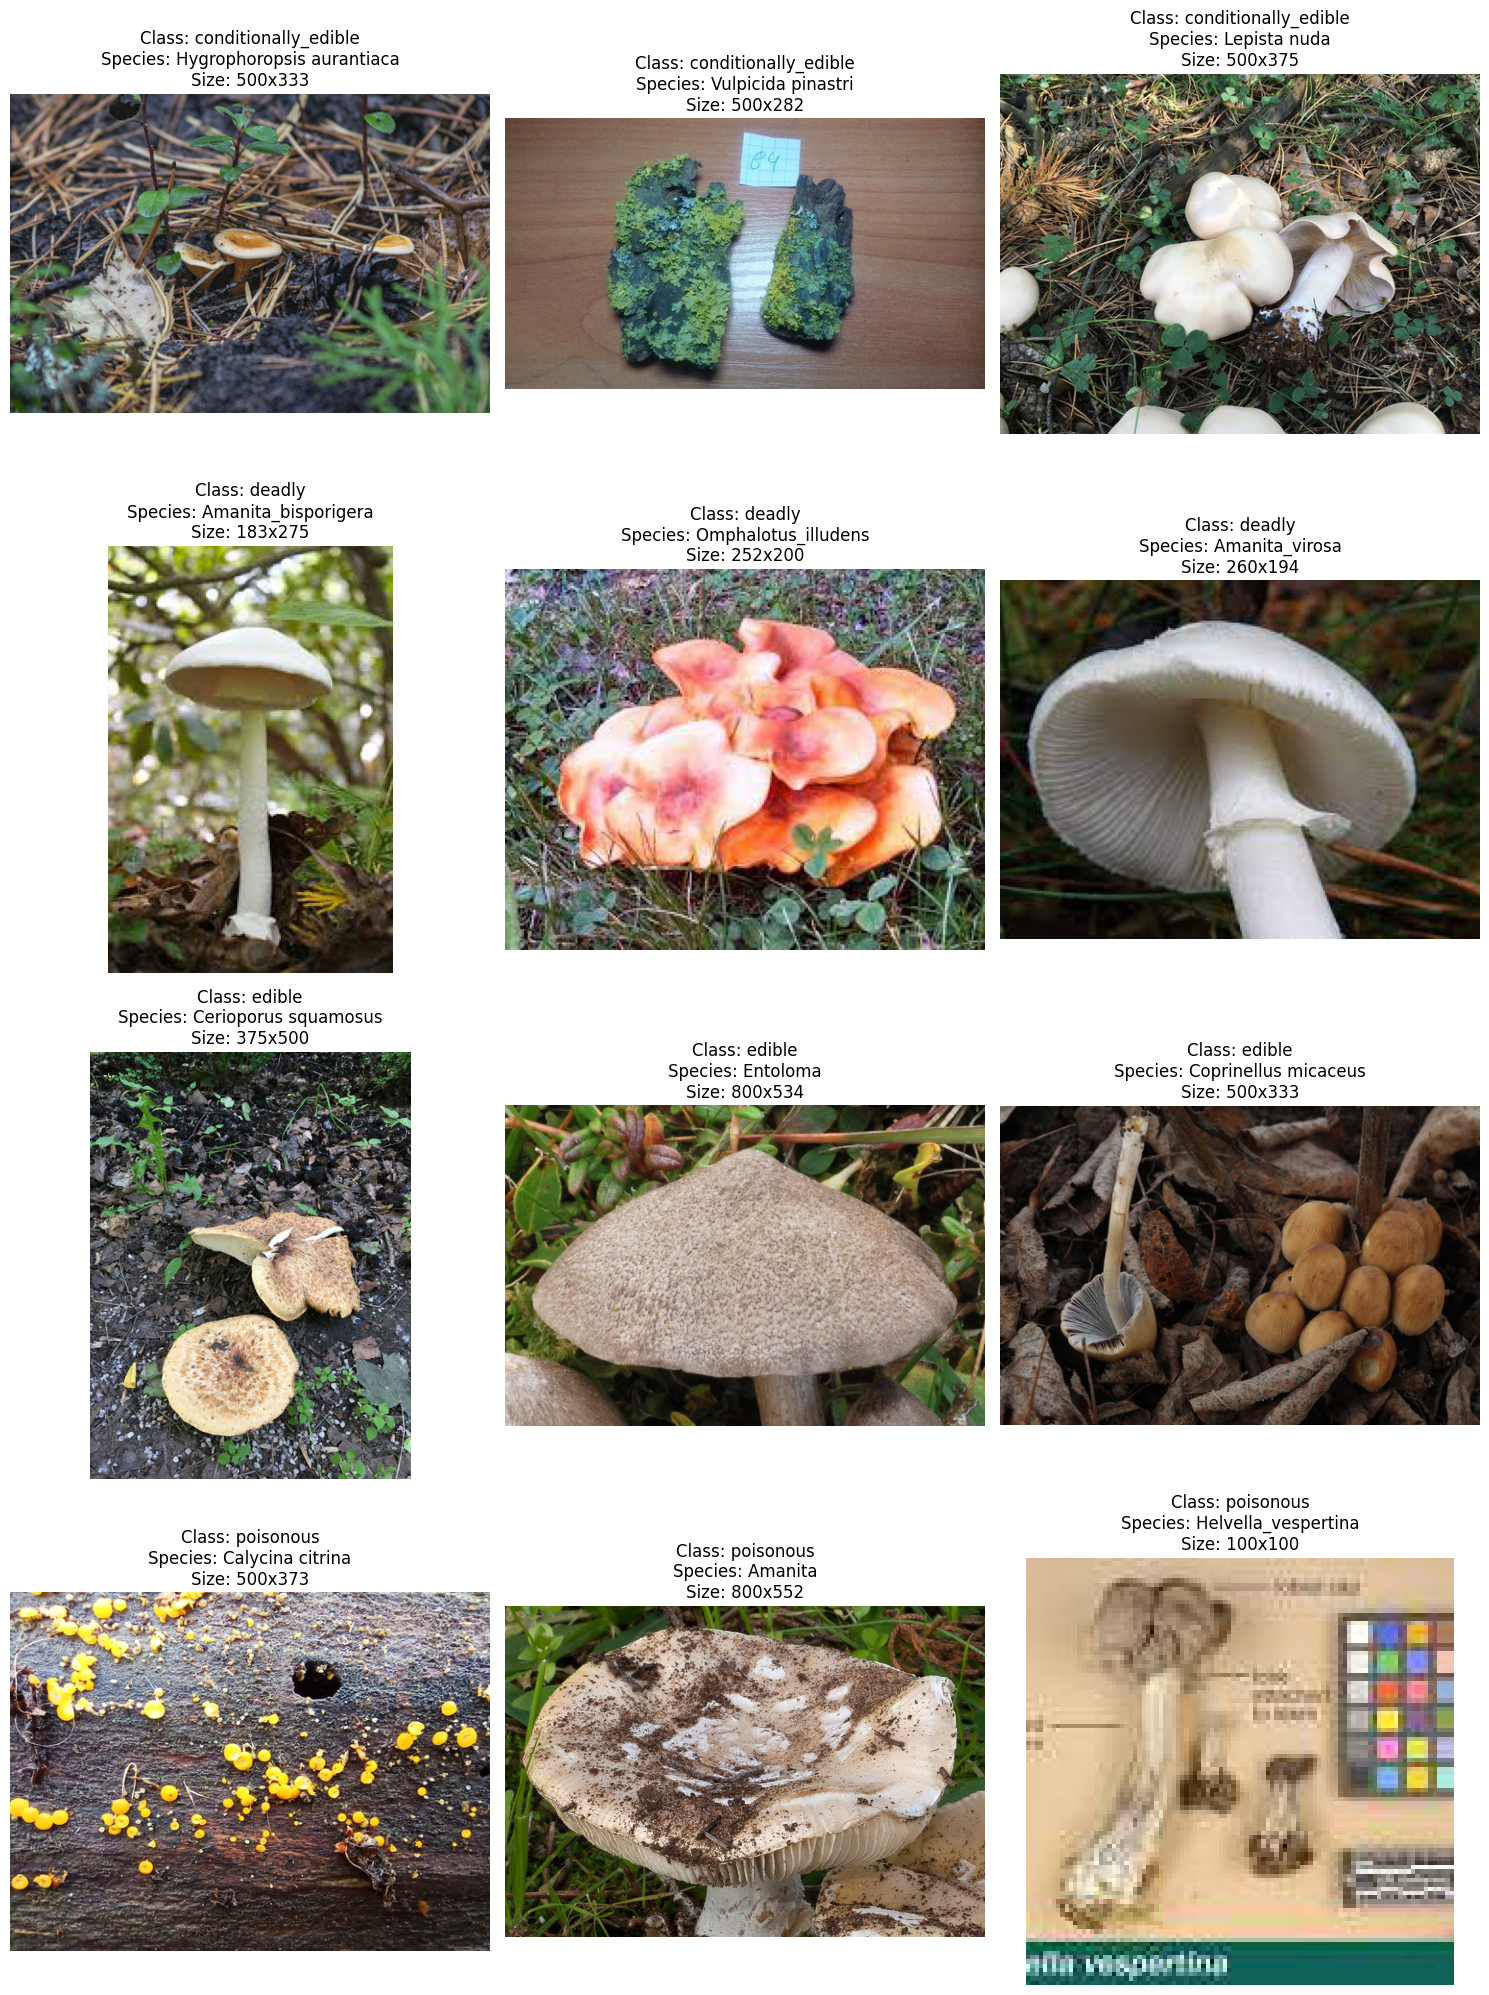

In [37]:
# sample per class
sample_images = data.groupby("class", group_keys=False).sample(3, random_state=42)
cols = 3
rows = (len(sample_images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title(f"Class: {row['class']}\nSpecies: {row['species']}\nSize: {row['width']}x{row['height']}")
    ax.axis('off')
plt.tight_layout()
plt.show()